In [4]:
import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score)
from sklearn.decomposition import PCA
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [6]:
# load all 3 datasets
def load_census():
    """Load Census-Income KDD via ucimlrepo."""
    from ucimlrepo import fetch_ucirepo
    print("Loading Census-Income (KDD) via ucimlrepo...")
    dataset = fetch_ucirepo(id=117)
    df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
    print(f"  ✓ Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    return df


def load_funds():
    """Load ETFs and Mutual Funds via kagglehub."""
    import kagglehub
    print("\nLoading Funds via kagglehub...")
    path = kagglehub.dataset_download("stefanoleone992/mutual-funds-and-etfs")
    etf_info = pd.read_csv(os.path.join(path, "ETFs.csv"))
    etf_info.columns = etf_info.columns.str.strip()
    mf_info = pd.read_csv(os.path.join(path, "MutualFunds.csv"))
    mf_info.columns = mf_info.columns.str.strip()
    print(f"  ✓ ETFs: {etf_info.shape}")
    print(f"  ✓ Mutual Funds: {mf_info.shape}")
    return etf_info, mf_info


def load_ce_survey(zip_path='./intrvw24.zip'):
    """Load CE Survey from local zip file."""
    print(f"\nLoading CE Survey from: {zip_path}")
    dfs = {}
    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_files = [f for f in z.namelist() if f.lower().endswith('.csv')]
        print(f"  Found {len(csv_files)} CSV files")
        for csv_file in csv_files:
            try:
                with z.open(csv_file) as f:
                    temp_df = pd.read_csv(f, low_memory=False)
                    key = os.path.basename(csv_file).lower().replace('.csv', '')
                    dfs[key] = temp_df
            except Exception as e:
                pass
    fmli_keys = sorted([k for k in dfs.keys() if 'fmli' in k])
    print(f"  ★ FMLI files: {fmli_keys}")
    return dfs

In [8]:
# feature engineering for UCI dataset
def engineer_census_features(df):
    """
    Feature engineering for Census-Income KDD.
    Columns: AAGE, ACLSWKR, AHGA, CAPGAIN, GAPLOSS, DIVVAL, WKSWORK, etc.
    """
    print("CENSUS-INCOME FEATURE ENGINEERING")
    feat = df.copy()

    # Clean
    print("[1] Cleaning...")
    for col in feat.select_dtypes(include='object').columns:
        feat[col] = feat[col].str.strip()
    for col in ['AAGE', 'AHRSPAY', 'CAPGAIN', 'GAPLOSS', 'DIVVAL', 'WKSWORK', 'ADTINK', 'ADTOCC', 'SEOTR']:
        if col in feat.columns:
            feat[col] = pd.to_numeric(feat[col], errors='coerce')

    # Age
    print("[2] Age features...")
    feat['age_group'] = pd.cut(feat['AAGE'], bins=[0, 25, 35, 45, 55, 65, 100],
        labels=['young_adult', 'early_career', 'mid_career', 'peak_earning', 'pre_retirement', 'retirement'])
    feat['years_to_retirement'] = np.maximum(65 - feat['AAGE'], 0)
    feat['investment_horizon'] = pd.cut(feat['years_to_retirement'], bins=[-1, 5, 15, 30, 100],
        labels=['short_term', 'medium_term', 'long_term', 'very_long_term'])

    # Income
    print("[3] Income features...")
    target_vals = feat['income'].unique()
    print(f"  Income target values: {target_vals}")
    feat['high_income'] = feat['income'].str.contains(r'50000\+|50000\.', regex=True, na=False).astype(int)
    feat['CAPGAIN'] = feat['CAPGAIN'].fillna(0)
    feat['GAPLOSS'] = feat['GAPLOSS'].fillna(0)
    feat['DIVVAL'] = pd.to_numeric(feat['DIVVAL'], errors='coerce').fillna(0)
    feat['total_investment_income'] = feat['CAPGAIN'] - feat['GAPLOSS'] + feat['DIVVAL']
    feat['has_investment_income'] = (feat['total_investment_income'] > 0).astype(int)
    feat['net_capital'] = feat['CAPGAIN'] - feat['GAPLOSS']
    feat['AHRSPAY'] = feat['AHRSPAY'].fillna(0)
    feat['WKSWORK'] = pd.to_numeric(feat['WKSWORK'], errors='coerce').fillna(0)
    feat['estimated_annual_wage'] = feat['AHRSPAY'] * 40 * feat['WKSWORK']
    feat['income_bracket'] = pd.cut(feat['estimated_annual_wage'],
        bins=[-1, 0, 20000, 40000, 75000, 150000, float('inf')],
        labels=['no_wage', 'low', 'lower_middle', 'middle', 'upper_middle', 'high'])

    # Employment
    print("[4] Employment features...")
    if 'ACLSWKR' in feat.columns:
        ret_map = {'Private': '401k_eligible', 'Federal government': '401k_eligible',
                   'Local government': '401k_eligible', 'State government': '401k_eligible',
                   'Self-employed-incorporated': 'sep_ira_eligible',
                   'Self-employed-not incorporated': 'sep_ira_eligible',
                   'Without pay': 'ira_only', 'Never worked': 'ira_only', 'Not in universe': 'ira_only'}
        feat['retirement_account_type'] = feat['ACLSWKR'].map(ret_map).fillna('ira_only')
        feat['is_self_employed'] = feat['ACLSWKR'].str.contains('Self', case=False, na=False).astype(int)
        feat['is_govt_employee'] = feat['ACLSWKR'].str.contains('government|gov', case=False, na=False).astype(int)
    feat['employment_stability'] = pd.cut(feat['WKSWORK'], bins=[-1, 0, 26, 48, 52],
        labels=['unemployed', 'part_year', 'most_year', 'full_year'])

    # Education
    print("[5] Education features...")
    if 'AHGA' in feat.columns:
        if feat['AHGA'].dtype == 'object':
            edu_map = {'Children': 0, 'Less than 1st grade': 1, '1st 2nd 3rd or 4th grade': 2,
                '5th or 6th grade': 3, '7th and 8th grade': 4, '9th grade': 5, '10th grade': 6,
                '11th grade': 7, '12th grade no diploma': 8, 'High school graduate': 9,
                'Some college but no degree': 10, 'Associates degree-occup /vocational': 11,
                'Associates degree-academic program': 12, 'Bachelors degree(BA AB BS)': 13,
                'Masters degree(MA MS MEng MEd MSW MBA)': 14,
                'Prof school degree (MD DDS DVM LLB JD)': 15, 'Doctorate degree(PhD EdD)': 16}
            feat['education_num'] = feat['AHGA'].map(edu_map)
        else:
            feat['education_num'] = pd.to_numeric(feat['AHGA'], errors='coerce')
        feat['education_level'] = pd.cut(feat['education_num'].fillna(0),
            bins=[-1, 8, 10, 12, 14, 16],
            labels=['below_hs', 'hs_grad', 'some_college', 'bachelors_plus', 'graduate'])

    # Household
    print("[6] Household features...")
    if 'AMARITL' in feat.columns:
        feat['is_married'] = feat['AMARITL'].str.contains('Married', case=False, na=False).astype(int)
    if 'HHDFMX' in feat.columns:
        feat['has_dependents'] = feat['HHDFMX'].astype(str).str.contains('child|Child', case=False, na=False).astype(int)
    if 'PARENT' in feat.columns:
        feat['has_children'] = (feat['PARENT'].astype(str).str.strip() != 'Not in universe').astype(int)
    if 'FILESTAT' in feat.columns:
        feat['files_jointly'] = feat['FILESTAT'].str.contains('Joint', case=False, na=False).astype(int)

    # Risk tolerance
    print("[7] Risk tolerance proxy...")
    age_risk = (1 - (feat['AAGE'].clip(18, 80) - 18) / (80 - 18)).astype(float)
    income_risk = feat['has_investment_income'].fillna(0).astype(float)
    horizon_map = {'very_long_term': 1.0, 'long_term': 0.75, 'medium_term': 0.5, 'short_term': 0.25}
    horizon_risk = feat['investment_horizon'].astype(str).map(horizon_map).fillna(0.5).astype(float)
    dependents_risk = 1 - feat.get('has_dependents', pd.Series(0, index=feat.index)).fillna(0).astype(float)
    feat['risk_tolerance_score'] = 0.35 * age_risk + 0.25 * income_risk + 0.25 * horizon_risk + 0.15 * dependents_risk
    feat['risk_tolerance'] = pd.cut(feat['risk_tolerance_score'], bins=[-0.01, 0.33, 0.66, 1.01],
        labels=['conservative', 'moderate', 'aggressive'])
    print(f"  Risk distribution: {feat['risk_tolerance'].value_counts().to_dict()}")

    clustering_features = ['AAGE', 'education_num', 'estimated_annual_wage', 'WKSWORK',
        'total_investment_income', 'has_investment_income', 'is_married',
        'years_to_retirement', 'risk_tolerance_score']
    clustering_features = [f for f in clustering_features if f in feat.columns]
    print(f"\n[Summary] New features: {len(feat.columns) - len(df.columns)}")
    print(f"  Clustering features: {clustering_features}")
    return feat, clustering_features

In [10]:
# Feature engineering for CE interview 2024 dataset
def rename_ce_columns(df):
    """Rename cryptic BLS codes to readable names."""
    rename_map = {
        'FINCBTXM': 'income_before_tax', 'FINCATXM': 'income_after_tax',
        'FINCBTAX': 'income_before_tax_alt', 'FINCATAX': 'income_after_tax_alt',
        'FSALARYM': 'salary_income', 'FNONFRMM': 'nonfarm_business_income',
        'FFRMINCM': 'farm_income', 'FRRETIRM': 'retirement_income',
        'FSSIXM': 'social_security_income', 'FINTRCCM': 'interest_dividend_income',
        'TOTEXPPQ': 'total_expenditure_this_quarter', 'TOTEXPCQ': 'total_expenditure_last_quarter',
        'FOODPQ': 'food_total_this_quarter', 'FOODCQ': 'food_total_last_quarter',
        'FDHOMEPQ': 'food_at_home_this_quarter', 'FDHOMECQ': 'food_at_home_last_quarter',
        'FDAWAYPQ': 'food_away_this_quarter', 'FDAWAYCQ': 'food_away_last_quarter',
        'EHOUSNGP': 'housing_total_this_quarter', 'EHOUSNGC': 'housing_total_last_quarter',
        'SHELTPQ': 'shelter_this_quarter', 'RENDWEPQ': 'rent_dwelling_this_quarter',
        'OWNRETPQ': 'owned_dwelling_this_quarter',
        'MRTPNPQ': 'mortgage_principal_this_quarter', 'MRTINTPQ': 'mortgage_interest_this_quarter',
        'UTILPQ': 'utilities_this_quarter', 'UTILCQ': 'utilities_last_quarter',
        'ELECTRPQ': 'electricity_this_quarter', 'NTLGASPQ': 'natural_gas_this_quarter',
        'TELEPHPQ': 'telephone_this_quarter',
        'TRANSPQ': 'transportation_this_quarter', 'TRANSCQ': 'transportation_last_quarter',
        'GASMOPQ': 'gasoline_this_quarter', 'PUBTRPQ': 'public_transit_this_quarter',
        'HEALTHPQ': 'healthcare_this_quarter', 'HEALTHCQ': 'healthcare_last_quarter',
        'MEDSRVPQ': 'medical_services_this_quarter', 'PREDRGPQ': 'prescription_drugs_this_quarter',
        'HLTHINNP': 'health_insurance_this_quarter',
        'ENTERTPQ': 'entertainment_this_quarter', 'ENTERTCQ': 'entertainment_last_quarter',
        'FEESADPQ': 'fees_admissions_this_quarter', 'READPQ': 'reading_this_quarter',
        'APPARPQ': 'apparel_this_quarter', 'APPARCQ': 'apparel_last_quarter',
        'EDUCAPQ': 'education_this_quarter', 'EDUCACQ': 'education_last_quarter',
        'PERINSPQ': 'personal_insurance_pensions_this_quarter',
        'LIFINSPQ': 'life_insurance_this_quarter', 'RETPENPQ': 'retirement_pension_this_quarter',
        'CASHCOPQ': 'cash_contributions_this_quarter',
        'TOBACCPQ': 'tobacco_this_quarter', 'ALCBEVPQ': 'alcohol_this_quarter',
        'PERSCAPQ': 'personal_care_this_quarter',
        'AGE_REF': 'age', 'AGE2': 'age_spouse', 'SEX_REF': 'sex',
        'MARITAL1': 'marital_status', 'EDUC_REF': 'education_level',
        'REF_RACE': 'race', 'FAM_SIZE': 'family_size', 'FAM_TYPE': 'family_type',
        'NO_EARNR': 'num_earners', 'PERSLT18': 'persons_under_18',
        'PERSOT64': 'persons_over_64', 'NUM_AUTO': 'num_vehicles',
        'CUTENURE': 'housing_tenure', 'ROOMSQ': 'num_rooms',
        'REGION': 'region', 'STATE': 'state', 'BLS_URBN': 'urban_rural',
        'NEWID': 'consumer_unit_id', 'QINTRVYR': 'interview_year',
        'QINTRVMO': 'interview_month', 'FINLWT21': 'survey_weight',
    }
    actual = {k: v for k, v in rename_map.items() if k in df.columns}
    df_r = df.rename(columns=actual)
    df_r = df_r.loc[:, ~df_r.columns.duplicated()]
    print(f"  Renamed {len(actual)} columns to readable names")
    return df_r


def engineer_ce_features(ce_fmli_df):
  
    print("CE SURVEY FEATURE ENGINEERING")
    feat = rename_ce_columns(ce_fmli_df.copy())
    print(f"  Shape: {feat.shape}")

    # Income
    print("[1] Income features...")
    income_col = None
    for c in ['income_before_tax', 'income_after_tax', 'income_before_tax_alt', 'income_after_tax_alt']:
        if c in feat.columns: income_col = c; break
    if income_col:
        feat['income'] = pd.to_numeric(feat[income_col], errors='coerce')
        feat = feat[feat['income'] > 0].copy()
        feat['income_percentile'] = feat['income'].rank(pct=True)
        feat['income_bracket_ce'] = pd.qcut(feat['income'], q=5,
            labels=['very_low', 'low', 'middle', 'upper_middle', 'high'], duplicates='drop')
        print(f"  Using '{income_col}': median=${feat['income'].median():,.0f}")
    else:
        print(f"  WARNING: No income column found!")

    # Spending
    print("[2] Spending features...")
    spend_map = {
        'food_home': 'food_at_home_this_quarter', 'food_away': 'food_away_this_quarter',
        'housing': 'housing_total_this_quarter', 'utilities': 'utilities_this_quarter',
        'transportation': 'transportation_this_quarter', 'healthcare': 'healthcare_this_quarter',
        'entertainment': 'entertainment_this_quarter', 'apparel': 'apparel_this_quarter',
        'education': 'education_this_quarter', 'insurance_pension': 'personal_insurance_pensions_this_quarter',
    }
    resolved = {}
    for cat, col in spend_map.items():
        if col in feat.columns:
            feat[f'spend_{cat}'] = pd.to_numeric(feat[col], errors='coerce').fillna(0).clip(lower=0)
            resolved[cat] = f'spend_{cat}'
    print(f"  Found: {list(resolved.keys())}")

    spend_cols = list(resolved.values())
    if 'total_expenditure_this_quarter' in feat.columns:
        feat['total_spending'] = pd.to_numeric(feat['total_expenditure_this_quarter'], errors='coerce').fillna(0)
    elif spend_cols:
        feat['total_spending'] = feat[spend_cols].sum(axis=1)

    # Savings rate
    print("[3] Savings rate...")
    if income_col and 'total_spending' in feat.columns:
        feat['total_spending_annual'] = feat['total_spending'] * 4
        feat['savings_amount'] = feat['income'] - feat['total_spending_annual']
        feat['savings_rate'] = (feat['savings_amount'] / feat['income']).clip(-1, 1)
        feat['savings_category'] = pd.cut(feat['savings_rate'],
            bins=[-float('inf'), 0, 0.1, 0.2, 0.3, float('inf')],
            labels=['negative_saver', 'minimal_saver', 'moderate_saver', 'good_saver', 'excellent_saver'])
        print(f"  Mean savings rate: {feat['savings_rate'].mean():.2%}")

    # Ratios & 50/30/20
    print("[4] Spending ratios & budget analysis...")
    if income_col:
        for cat, col in resolved.items():
            feat[f'ratio_{cat}'] = (feat[col] * 4 / feat['income']).clip(0, 2)
        needs = [resolved[c] for c in ['housing', 'utilities', 'food_home', 'transportation', 'healthcare', 'insurance_pension'] if c in resolved]
        wants = [resolved[c] for c in ['food_away', 'entertainment', 'apparel', 'education'] if c in resolved]
        if needs: feat['total_needs'] = feat[needs].sum(axis=1) * 4; feat['needs_ratio'] = (feat['total_needs'] / feat['income']).clip(0, 2)
        if wants: feat['total_wants'] = feat[wants].sum(axis=1) * 4; feat['wants_ratio'] = (feat['total_wants'] / feat['income']).clip(0, 2)
        if all(c in feat.columns for c in ['needs_ratio', 'wants_ratio', 'savings_rate']):
            feat['budget_health_score'] = 1 - (abs(feat['needs_ratio'] - 0.50) + abs(feat['wants_ratio'] - 0.30) + abs(feat['savings_rate'] - 0.20)).clip(0, 1)

    # Anomalies
    print("[5] Anomaly flags...")
    if 'ratio_housing' in feat.columns: feat['high_housing_flag'] = (feat['ratio_housing'] > 0.40).astype(int)
    if 'needs_ratio' in feat.columns: feat['high_needs_flag'] = (feat['needs_ratio'] > 0.65).astype(int)
    if 'ratio_food_away' in feat.columns: feat['high_dining_flag'] = (feat['ratio_food_away'] > 0.10).astype(int)
    if 'savings_rate' in feat.columns: feat['negative_savings_flag'] = (feat['savings_rate'] < 0).astype(int)
    anomaly_cols = [c for c in feat.columns if c.endswith('_flag')]
    if anomaly_cols: feat['total_anomalies'] = feat[anomaly_cols].sum(axis=1)

    # Per capita
    if 'family_size' in feat.columns:
        feat['family_size_num'] = pd.to_numeric(feat['family_size'], errors='coerce').fillna(1).clip(lower=1)
        if income_col: feat['income_per_capita'] = feat['income'] / feat['family_size_num']

    budget_features = [c for c in feat.columns if c.startswith('ratio_') or
        c in ['savings_rate', 'budget_health_score', 'needs_ratio', 'wants_ratio', 'income_percentile', 'total_anomalies']]
    print(f"\n[Summary] Budget features: {len(budget_features)}")
    return feat, budget_features


In [12]:
# feature engineering for MF and ETF datasets
def engineer_fund_features(etf_df, mf_df):
   
    print("ETF / MUTUAL FUND FEATURE ENGINEERING")
    etf_df = etf_df.copy(); mf_df = mf_df.copy()
    etf_df['investment_type'] = 'ETF'; mf_df['investment_type'] = 'Mutual Fund'
    common_cols = list(set(etf_df.columns) & set(mf_df.columns))
    feat = pd.concat([etf_df[common_cols], mf_df[common_cols]], ignore_index=True)
    print(f"  Combined: {feat.shape}")

    # Expense ratio
    print("[1] Expense ratio...")
    for c in ['fund_annual_report_net_expense_ratio', 'net_expense_ratio', 'expense_ratio']:
        if c in feat.columns:
            feat['expense_ratio'] = pd.to_numeric(feat[c], errors='coerce'); break
    if 'expense_ratio' in feat.columns:
        feat['expense_category'] = pd.cut(feat['expense_ratio'], bins=[-0.01, 0.002, 0.005, 0.01, 0.02, float('inf')],
            labels=['ultra_low', 'low', 'moderate', 'high', 'very_high'])
        max_exp = feat['expense_ratio'].quantile(0.99)
        feat['cost_score'] = 1 - (feat['expense_ratio'] / max_exp).clip(0, 1)

    # Risk
    print("[2] Risk metrics...")
    for new, old in [('risk_beta', 'fund_beta'), ('risk_alpha', 'fund_alpha'),
                     ('risk_sharpe', 'fund_sharpe_ratio'), ('risk_treynor', 'fund_treynor_ratio'),
                     ('risk_stdev', 'fund_standard_deviation'), ('risk_mean_return', 'fund_mean_annual_return')]:
        if old in feat.columns: feat[new] = pd.to_numeric(feat[old], errors='coerce')
    if 'risk_beta' in feat.columns and 'risk_stdev' in feat.columns:
        beta_n = (feat['risk_beta'].clip(0, 3) / 3).fillna(0.5)
        stdev_n = (feat['risk_stdev'] / feat['risk_stdev'].quantile(0.99)).clip(0, 1).fillna(0.5)
        feat['fund_risk_score'] = 0.5 * beta_n + 0.5 * stdev_n
    elif 'risk_beta' in feat.columns:
        feat['fund_risk_score'] = (feat['risk_beta'].clip(0, 3) / 3).fillna(0.5)
    if 'fund_risk_score' in feat.columns:
        feat['fund_risk_tier'] = pd.cut(feat['fund_risk_score'], bins=[-0.01, 0.33, 0.66, 1.01],
            labels=['conservative', 'moderate', 'aggressive'])

    # Performance
    print("[3] Performance...")
    for new, old in [('return_ytd', 'fund_return_ytd'), ('return_1yr', 'fund_return_1year'),
                     ('return_3yr', 'fund_return_3years'), ('return_5yr', 'fund_return_5years')]:
        if old in feat.columns: feat[new] = pd.to_numeric(feat[old], errors='coerce')
    ret_cols = [c for c in ['return_1yr', 'return_3yr', 'return_5yr'] if c in feat.columns]
    if ret_cols: feat['avg_return'] = feat[ret_cols].mean(axis=1)
    if 'avg_return' in feat.columns and 'expense_ratio' in feat.columns:
        feat['return_per_cost'] = feat['avg_return'] / feat['expense_ratio'].replace(0, np.nan)
    if len(ret_cols) >= 2:
        feat['return_consistency'] = 1 / (1 + feat[ret_cols].std(axis=1).fillna(10))

    # Portfolio
    print("[4] Portfolio composition...")
    for asset in ['stocks', 'bonds', 'cash', 'other']:
        col = f'portfolio_{asset}'
        if col in feat.columns: feat[f'alloc_{asset}'] = pd.to_numeric(feat[col], errors='coerce').fillna(0) / 100
    if all(f'alloc_{a}' in feat.columns for a in ['stocks', 'bonds']):
        feat['asset_class_derived'] = np.select(
            [feat['alloc_stocks'] >= 0.80, (feat['alloc_stocks'] >= 0.40) & (feat['alloc_stocks'] < 0.80), feat['alloc_bonds'] >= 0.80],
            ['equity', 'balanced', 'fixed_income'], default='other')

    # Sectors
    print("[5] Sector diversification...")
    sector_cols = [c for c in feat.columns if c.startswith('sector_')]
    if sector_cols:
        sd = feat[sector_cols].apply(pd.to_numeric, errors='coerce').fillna(0) / 100
        feat['sector_diversification'] = sd.apply(lambda r: -np.sum(r[r > 0] * np.log(r[r > 0] + 1e-10)), axis=1)
        feat['top_sector_concentration'] = sd.max(axis=1)

    # Size & age
    print("[6] Fund size & type...")
    if 'total_net_assets' in feat.columns:
        feat['fund_size'] = pd.to_numeric(feat['total_net_assets'], errors='coerce')
        feat['fund_size_log'] = np.log1p(feat['fund_size'].fillna(0).clip(lower=0))
    if 'inception_date' in feat.columns:
        feat['inception'] = pd.to_datetime(feat['inception_date'], errors='coerce')
        feat['fund_age_years'] = (pd.Timestamp('2021-11-01') - feat['inception']).dt.days / 365.25
        feat['is_established'] = (feat['fund_age_years'] > 5).astype(int)
    feat['is_etf'] = (feat['investment_type'] == 'ETF').astype(int)

    # Composite
    print("[7] Composite score...")
    scores = {}
    if 'cost_score' in feat.columns: scores['cost'] = feat['cost_score'].fillna(0.5)
    if 'risk_sharpe' in feat.columns:
        s = feat['risk_sharpe']
        scores['perf'] = ((s - s.quantile(0.01)) / (s.quantile(0.99) - s.quantile(0.01))).clip(0, 1).fillna(0.5)
    if 'sector_diversification' in feat.columns:
        scores['div'] = (feat['sector_diversification'] / feat['sector_diversification'].quantile(0.99)).clip(0, 1).fillna(0.5)
    if 'is_established' in feat.columns:
        scores['mat'] = feat['is_established'].astype(float)
    if scores: feat['composite_score'] = pd.DataFrame(scores).mean(axis=1)

    matching_features = [f for f in ['fund_risk_score', 'expense_ratio', 'cost_score', 'avg_return',
        'return_consistency', 'sector_diversification', 'top_sector_concentration', 'composite_score']
        if f in feat.columns]
    print(f"\n[Summary] Matching features: {matching_features}")
    return feat, matching_features

In [14]:
#  K-MEANS CLUSTERING   
def find_optimal_k(X_scaled, k_range=range(2, 11), sample_size=20000):
    """Evaluate K=2..10, recommend best silhouette."""
    print("\n" + "=" * 60)
    print("FINDING OPTIMAL K")
    print("=" * 60)
    if len(X_scaled) > sample_size:
        print(f"  Sampling {sample_size} rows (full: {len(X_scaled):,})")
        X_s = X_scaled.sample(n=sample_size, random_state=42)
    else:
        X_s = X_scaled

    results = {'k': [], 'inertia': [], 'silhouette': [], 'calinski_harabasz': [], 'davies_bouldin': []}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
        lab = km.fit_predict(X_s)
        sil = silhouette_score(X_s, lab)
        ch = calinski_harabasz_score(X_s, lab)
        db = davies_bouldin_score(X_s, lab)
        results['k'].append(k); results['inertia'].append(km.inertia_)
        results['silhouette'].append(sil); results['calinski_harabasz'].append(ch); results['davies_bouldin'].append(db)
        print(f"    K={k}: Silhouette={sil:.4f}  CH={ch:.0f}  DB={db:.4f}  Inertia={km.inertia_:.0f}")

    best = np.argmax(results['silhouette'])
    rec_k = results['k'][best]
    print(f"\n  ★ Recommended K = {rec_k} (silhouette: {results['silhouette'][best]:.4f})")
    return results, rec_k


def plot_optimal_k(results, rec_k, save_path=None):
    """4-panel K evaluation plot."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Optimal K Selection', fontsize=16, fontweight='bold')
    k = results['k']

    axes[0,0].plot(k, results['inertia'], 'bo-', lw=2, ms=8)
    axes[0,0].axvline(rec_k, color='red', ls='--', alpha=0.7, label=f'K={rec_k}')
    axes[0,0].set(xlabel='K', ylabel='Inertia', title='Elbow Method'); axes[0,0].legend()

    colors = ['red' if v == rec_k else 'steelblue' for v in k]
    axes[0,1].bar(k, results['silhouette'], color=colors)
    axes[0,1].set(xlabel='K', ylabel='Silhouette', title='Silhouette (higher=better)')

    axes[1,0].plot(k, results['calinski_harabasz'], 'gs-', lw=2, ms=8)
    axes[1,0].axvline(rec_k, color='red', ls='--', alpha=0.7)
    axes[1,0].set(xlabel='K', ylabel='CH Index', title='Calinski-Harabasz (higher=better)')

    axes[1,1].plot(k, results['davies_bouldin'], 'r^-', lw=2, ms=8)
    axes[1,1].axvline(rec_k, color='red', ls='--', alpha=0.7)
    axes[1,1].set(xlabel='K', ylabel='DB Index', title='Davies-Bouldin (lower=better)')

    for ax in axes.flat: ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def run_kmeans(X_scaled, k):
    """Fit K-Means."""
    print(f"\n{'='*60}\nRUNNING K-MEANS (K={k})\n{'='*60}")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = kmeans.fit_predict(X_scaled)

    n_sample = min(20000, len(X_scaled))
    idx = np.random.RandomState(42).choice(len(X_scaled), n_sample, replace=False)
    sil = silhouette_score(X_scaled.iloc[idx], labels[idx])
    print(f"  Converged in {kmeans.n_iter_} iters | Inertia: {kmeans.inertia_:.0f} | Silhouette: {sil:.4f}")

    unique, counts = np.unique(labels, return_counts=True)
    for c, n in zip(unique, counts): print(f"    Cluster {c}: {n:,} ({n/len(labels)*100:.1f}%)")
    return kmeans, labels


#CLUSTER PROFILING & VISUALIZATION      
def profile_clusters(df, labels, feature_names):
    """Profile clusters and auto-name personas."""
    print(f"\n{'='*60}\nCLUSTER PROFILING\n{'='*60}")
    df_c = df.copy(); df_c['cluster'] = labels
    num_cols = [c for c in feature_names if c in df_c.columns and df_c[c].dtype in ['float64','int64','float32','int32']]
    profiles = df_c.groupby('cluster')[num_cols].mean()
    print("\n  Mean features per cluster:")
    print(profiles.round(2).to_string())

    # Persona naming
    persona_names = {}
    for cid in profiles.index:
        r = profiles.loc[cid]
        age = r.get('AAGE', 40); risk = r.get('risk_tolerance_score', 0.5)
        income = r.get('estimated_annual_wage', 0); married = r.get('is_married', 0)
        has_inv = r.get('has_investment_income', 0)

        if age < 30 and risk > 0.6: name = "Young Aggressive Investor"
        elif age < 30: name = "Young Conservative Starter"
        elif 30 <= age < 45 and married > 0.5: name = "Family Builder"
        elif 30 <= age < 45 and income > profiles['estimated_annual_wage'].median(): name = "Mid-Career High Earner"
        elif 30 <= age < 45: name = "Mid-Career Growth Seeker"
        elif 45 <= age < 55 and has_inv > 0.3: name = "Wealth Accumulator"
        elif 45 <= age < 55: name = "Peak Earner"
        elif 55 <= age < 65: name = "Pre-Retiree"
        elif age >= 65: name = "Retiree"
        else: name = f"Segment {cid}"

        rl = "Aggressive" if risk > 0.6 else "Moderate" if risk > 0.35 else "Conservative"
        persona_names[cid] = f"{name} ({rl})"

    print("\n  ★ Personas:")
    for cid, n in persona_names.items(): print(f"    Cluster {cid}: {n} — {(labels==cid).sum():,} users")
    return profiles, persona_names


def plot_clusters_pca(X_scaled, labels, persona_names, save_path=None):
    """PCA scatter."""
    pca = PCA(n_components=2); X_pca = pca.fit_transform(X_scaled)
    fig, ax = plt.subplots(figsize=(12, 8))
    for cid, color in zip(np.unique(labels), plt.cm.Set2(np.linspace(0, 1, len(np.unique(labels))))):
        mask = labels == cid
        if mask.sum() > 5000:
            idx = np.random.choice(np.where(mask)[0], 5000, replace=False)
            mask = np.zeros(len(labels), dtype=bool); mask[idx] = True
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color],
                   label=persona_names.get(cid, f"C{cid}"), alpha=0.4, s=15)
    ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
           ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
           title='User Segments — PCA')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_silhouette(X_scaled, labels, k, save_path=None):
    """Silhouette plot."""
    if len(X_scaled) > 15000:
        idx = np.random.choice(len(X_scaled), 15000, replace=False)
        X_s = X_scaled.iloc[idx]; lab_s = labels[idx]
    else: X_s = X_scaled; lab_s = labels
    scores = silhouette_samples(X_s, lab_s)
    fig, ax = plt.subplots(figsize=(10, 7))
    y_lo = 10; colors = plt.cm.Set2(np.linspace(0, 1, k))
    for i in range(k):
        cs = np.sort(scores[lab_s == i]); y_hi = y_lo + len(cs)
        ax.fill_betweenx(np.arange(y_lo, y_hi), 0, cs, facecolor=colors[i], alpha=0.7)
        ax.text(-0.05, y_lo + 0.5 * len(cs), str(i), fontsize=12); y_lo = y_hi + 10
    avg = silhouette_score(X_s, lab_s)
    ax.axvline(avg, color='red', ls='--', lw=2, label=f'Avg: {avg:.3f}')
    ax.set(xlabel='Silhouette Coefficient', ylabel='Cluster', title=f'Silhouette Analysis (K={k})')
    ax.legend(fontsize=12); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_profile_heatmap(profiles, persona_names, feature_names, save_path=None):
    """Heatmap of cluster profiles."""
    fig, ax = plt.subplots(figsize=(14, 6))
    nf = [f for f in feature_names if f in profiles.columns]
    pn = pd.DataFrame(MinMaxScaler().fit_transform(profiles[nf]), columns=nf,
                       index=[persona_names.get(i, f"C{i}") for i in profiles.index])
    sns.heatmap(pn, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('Cluster Profiles', fontsize=14, fontweight='bold')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right'); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_cluster_distribution(labels, persona_names, save_path=None):
    """Bar chart of cluster sizes."""
    fig, ax = plt.subplots(figsize=(10, 6))
    unique, counts = np.unique(labels, return_counts=True)
    names = [persona_names.get(c, f"C{c}") for c in unique]
    colors = plt.cm.Set2(np.linspace(0, 1, len(unique)))
    bars = ax.barh(names, counts, color=colors, height=0.6)
    for b, c in zip(bars, counts):
        ax.text(b.get_width() + 500, b.get_y() + b.get_height()/2, f'{c:,} ({c/len(labels)*100:.1f}%)', va='center')
    ax.set(xlabel='Users', title='User Segment Distribution'); ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# CLUSTER to RECOMMENDATION MAPPING 
def map_clusters_to_recommendations(profiles, persona_names):
    """Map clusters to fund tiers & financial products."""
    print(f"\n{'='*60}\nCLUSTER → RECOMMENDATION MAPPING\n{'='*60}")
    mappings = []
    for cid in profiles.index:
        r = profiles.loc[cid]; risk = r.get('risk_tolerance_score', 0.5)
        age = r.get('AAGE', 40); income = r.get('estimated_annual_wage', 0)
        horizon = r.get('years_to_retirement', 25)

        if risk > 0.6: tier, stocks, bonds = 'aggressive', '80-100%', '0-20%'
        elif risk > 0.35: tier, stocks, bonds = 'moderate', '50-70%', '30-50%'
        else: tier, stocks, bonds = 'conservative', '20-40%', '60-80%'

        savings = 'HYSA + CDs' if (risk < 0.3 or horizon < 5) else ('HYSA + Bond Funds' if horizon < 15 else 'HYSA (emergency fund only)')
        retirement = 'Roth IRA + 401k' if income > 50000 else ('Traditional IRA + 401k match' if income > 25000 else 'Roth IRA')

        m = {'cluster_id': cid, 'persona': persona_names.get(cid), 'fund_risk_tier': tier,
             'stocks': stocks, 'bonds': bonds, 'savings': savings, 'retirement': retirement,
             'risk_score': round(risk, 3), 'avg_age': round(age, 1), 'avg_income': round(income, 0)}
        mappings.append(m)
        print(f"\n  Cluster {cid}: {m['persona']}")
        print(f"    → {tier} | {stocks} stocks | {savings} | {retirement}")
    return pd.DataFrame(mappings)

Loading Census-Income (KDD) via ucimlrepo...
  ✓ Shape: (199523, 42)
  Columns: ['AAGE', 'ACLSWKR', 'ADTINK', 'ADTOCC', 'AHGA', 'AHSCOL', 'AMARITL', 'AMJIND', 'AMJOCC', 'ARACE', 'AREORGN', 'ASEX', 'AUNMEM', 'AUNTYPE', 'AWKSTAT', 'CAPGAIN', 'GAPLOSS', 'DIVVAL', 'FILESTAT', 'GRINREG', 'GRINST', 'HHDFMX', 'HHDREL', 'MARSUPWRT', 'MIGMTR1', 'MIGMTR3', 'MIGMTR4', 'MIGSAME', 'MIGSUN', 'NOEMP', 'PARENT', 'PEFNTVTY', 'PEMNTVTY', 'PENATVTY', 'PRCITSHP', 'SEOTR', 'VETQVA', 'VETYN', 'WKSWORK', 'AHRSPAY', 'year', 'income']
CENSUS-INCOME FEATURE ENGINEERING
[1] Cleaning...
[2] Age features...
[3] Income features...
  Income target values: ['-50000' '50000+.']
[4] Employment features...
[5] Education features...
[6] Household features...
[7] Risk tolerance proxy...
  Risk distribution: {'moderate': 127142, 'aggressive': 47439, 'conservative': 24942}

[Summary] New features: 21
  Clustering features: ['AAGE', 'education_num', 'estimated_annual_wage', 'WKSWORK', 'total_investment_income', 'has_investme

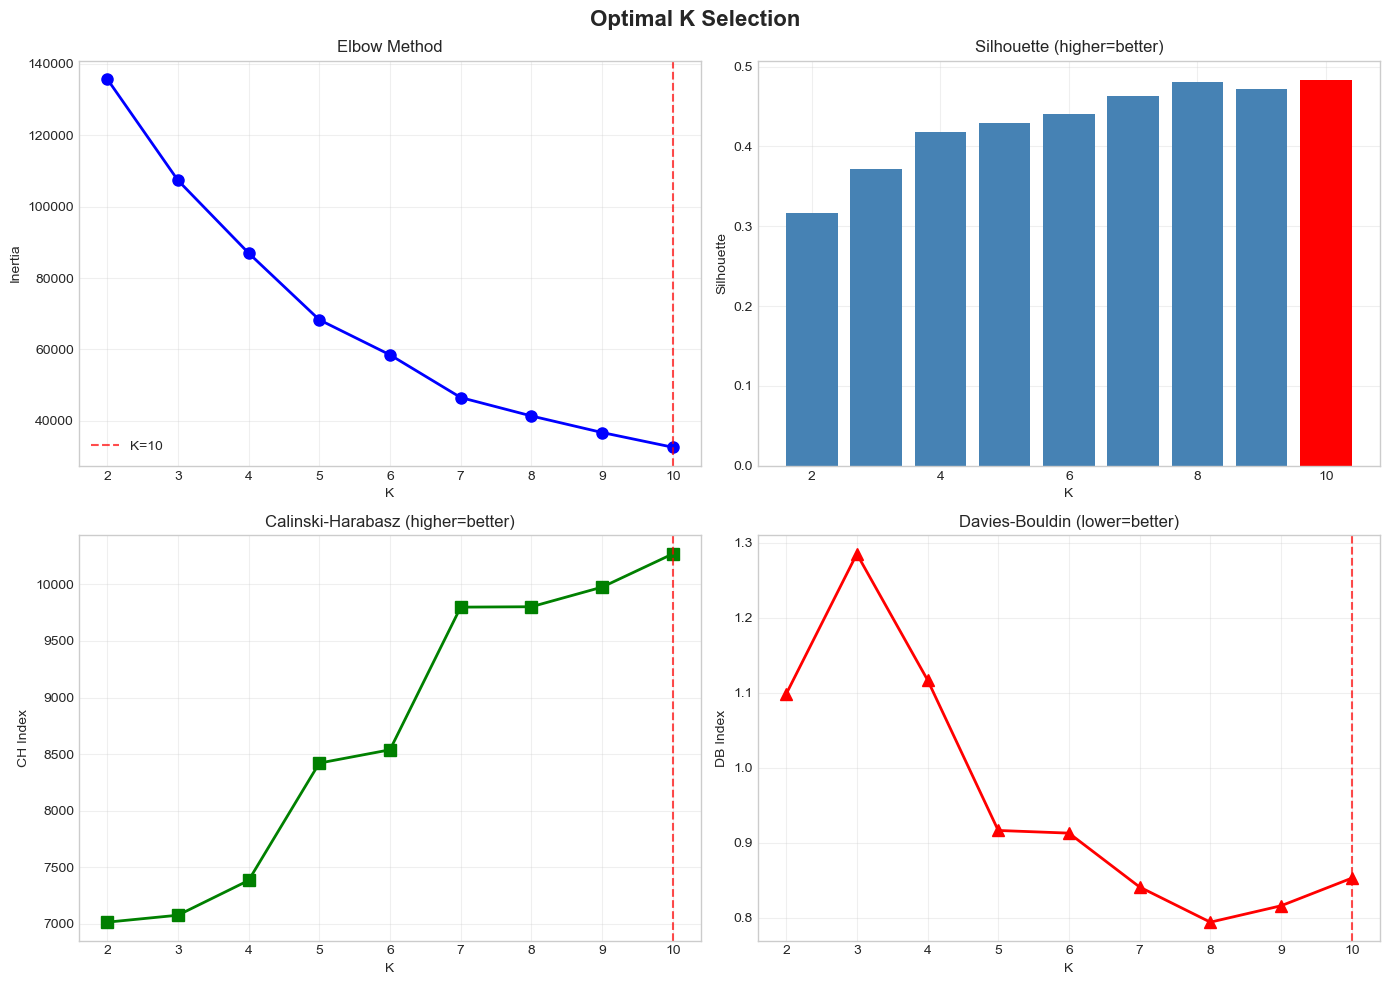


  Using K = 10

RUNNING K-MEANS (K=10)
  Converged in 8 iters | Inertia: 332884 | Silhouette: 0.4833
    Cluster 0: 49,421 (24.8%)
    Cluster 1: 21,716 (10.9%)
    Cluster 2: 49,142 (24.6%)
    Cluster 3: 8,431 (4.2%)
    Cluster 4: 6,096 (3.1%)
    Cluster 5: 442 (0.2%)
    Cluster 6: 11,515 (5.8%)
    Cluster 7: 10,604 (5.3%)
    Cluster 8: 26,289 (13.2%)
    Cluster 9: 15,867 (8.0%)

CLUSTER PROFILING

  Mean features per cluster:
          AAGE  education_num  estimated_annual_wage  WKSWORK  total_investment_income  has_investment_income  is_married  years_to_retirement  risk_tolerance_score
cluster                                                                                                                                                             
0        34.98          10.07               47512.45    49.69                   -73.85                   0.00        1.00                30.02                  0.60
1        65.26           8.14               14747.28    14.66    

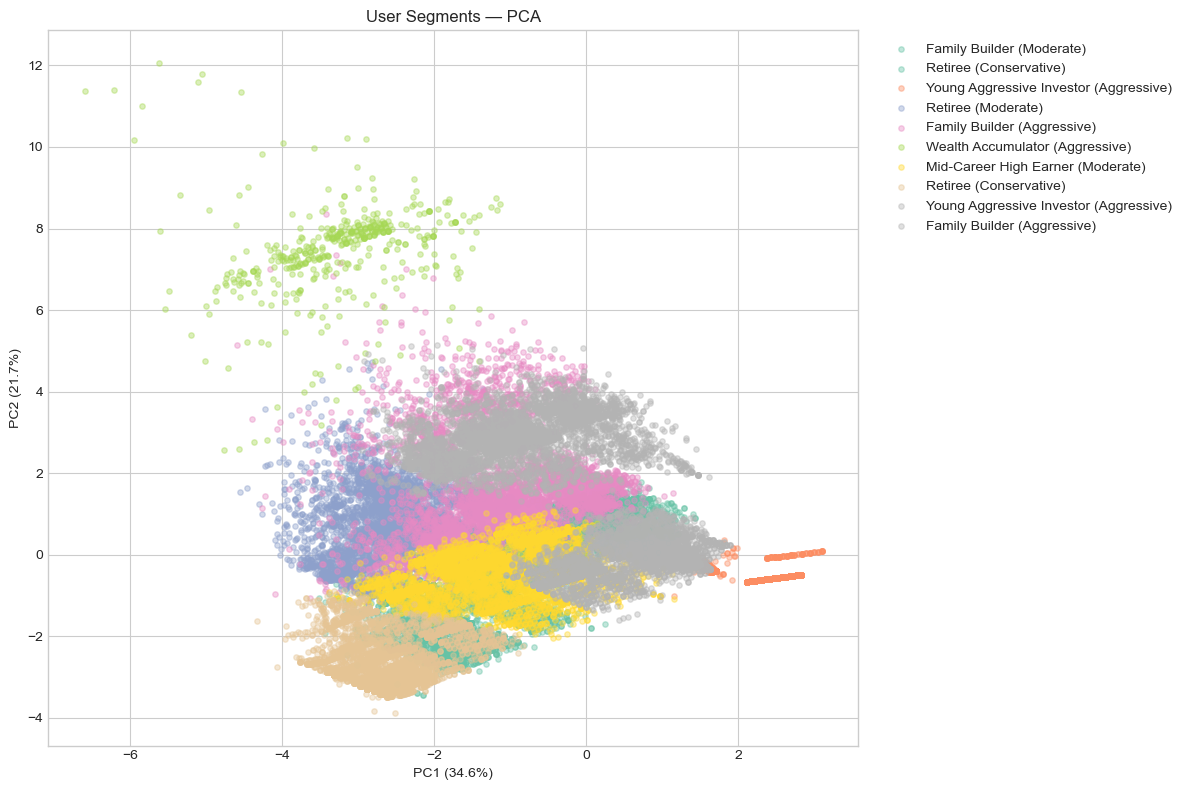

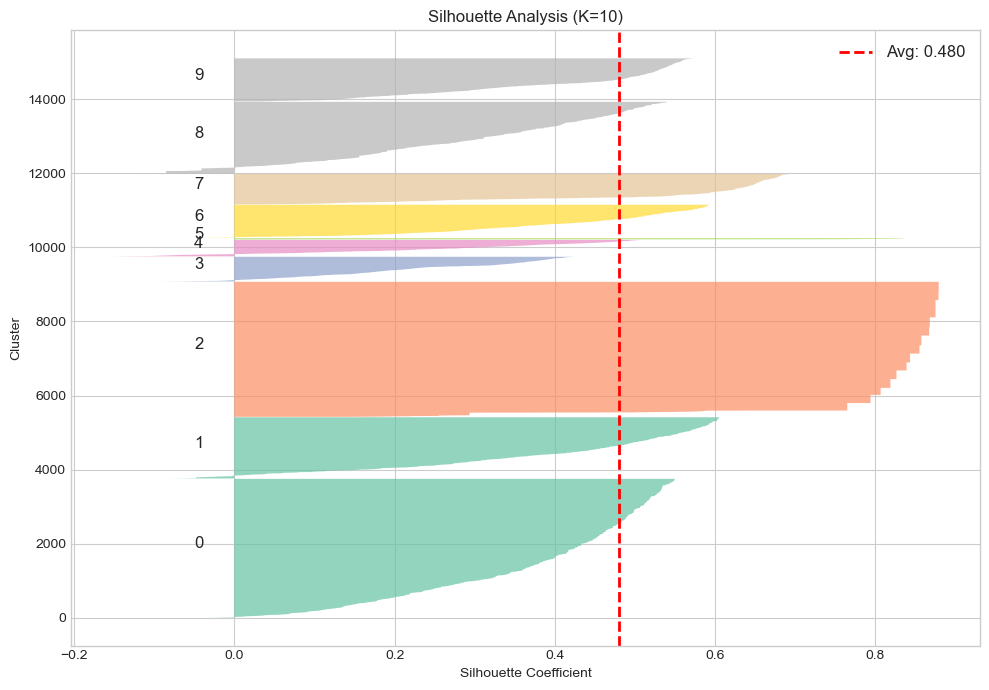

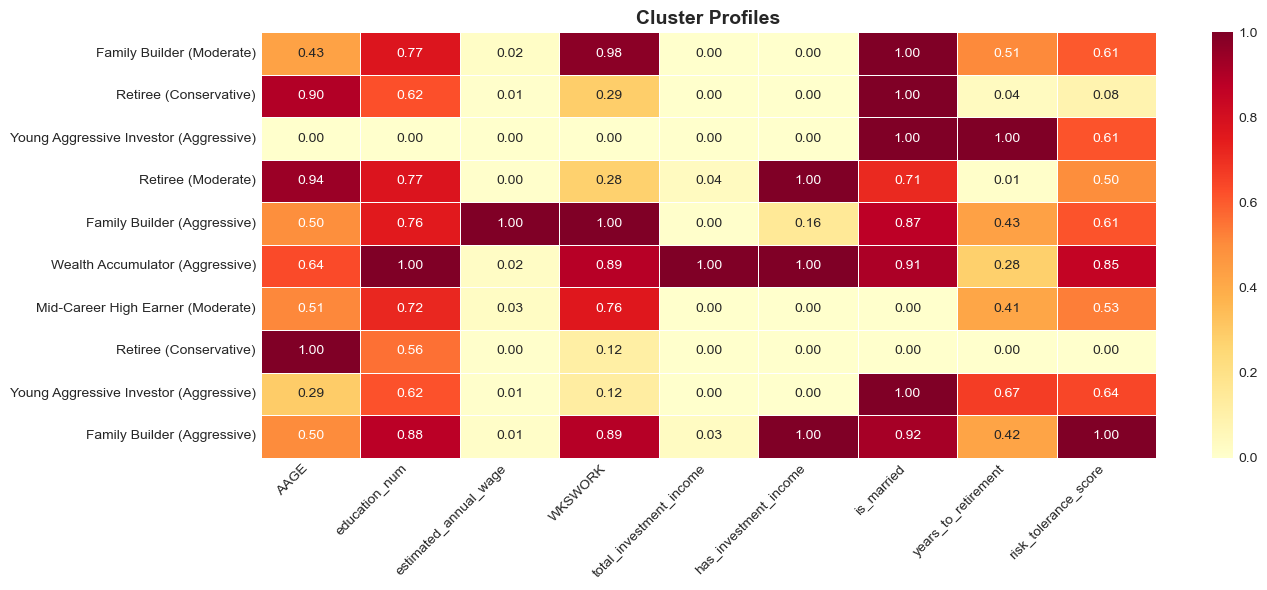

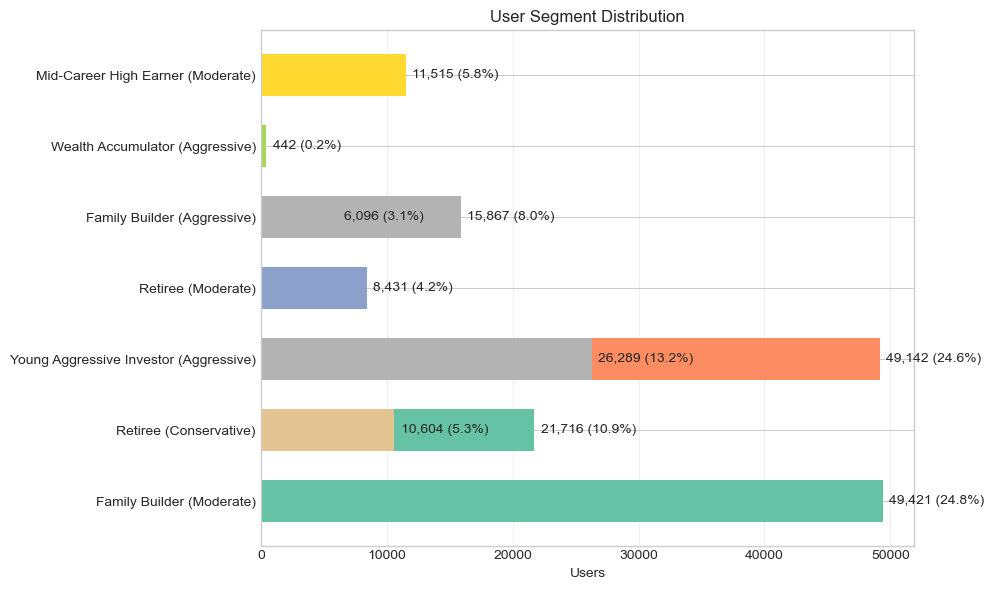


CLUSTER → RECOMMENDATION MAPPING

  Cluster 0: Family Builder (Moderate)
    → moderate | 50-70% stocks | HYSA (emergency fund only) | Traditional IRA + 401k match

  Cluster 1: Retiree (Conservative)
    → conservative | 20-40% stocks | HYSA + CDs | Roth IRA

  Cluster 2: Young Aggressive Investor (Aggressive)
    → aggressive | 80-100% stocks | HYSA (emergency fund only) | Roth IRA

  Cluster 3: Retiree (Moderate)
    → moderate | 50-70% stocks | HYSA + CDs | Roth IRA

  Cluster 4: Family Builder (Aggressive)
    → aggressive | 80-100% stocks | HYSA (emergency fund only) | Roth IRA + 401k

  Cluster 5: Wealth Accumulator (Aggressive)
    → aggressive | 80-100% stocks | HYSA (emergency fund only) | Roth IRA + 401k

  Cluster 6: Mid-Career High Earner (Moderate)
    → moderate | 50-70% stocks | HYSA (emergency fund only) | Roth IRA + 401k

  Cluster 7: Retiree (Conservative)
    → conservative | 20-40% stocks | HYSA + CDs | Roth IRA

  Cluster 8: Young Aggressive Investor (Aggressive)

In [16]:
def main():
    os.makedirs('data/processed', exist_ok=True)
    os.makedirs('reports/figures', exist_ok=True)


    # 1. Census
    census_df = load_census()
    census_feat, clustering_features = engineer_census_features(census_df)
    census_feat.to_csv('data/processed/census_features.csv', index=False)
    print("  ✓ Census features saved\n")

    # 2. Funds
    etf_info, mf_info = load_funds()
    fund_feat, matching_features = engineer_fund_features(etf_info, mf_info)
    fund_feat.to_csv('data/processed/fund_features.csv', index=False)
    print("  ✓ Fund features saved\n")

    # 3. CE Survey
    CE_ZIP_PATH = './intrvw24.zip'
    if os.path.exists(CE_ZIP_PATH):
        ce_dfs = load_ce_survey(CE_ZIP_PATH)
        fmli_keys = sorted([k for k in ce_dfs.keys() if 'fmli' in k])
        if fmli_keys:
            ce_combined = pd.concat([ce_dfs[k] for k in fmli_keys], ignore_index=True)
            print(f"  Combined FMLI: {ce_combined.shape}")
            ce_feat, budget_features = engineer_ce_features(ce_combined)
            ce_feat.to_csv('data/processed/ce_survey_features.csv', index=False)
            print("  ✓ CE features saved\n")
    else:
        print(f"  CE zip not found at {CE_ZIP_PATH}, skipping...\n")


    # Prepare
    X = census_feat[clustering_features].apply(pd.to_numeric, errors='coerce').fillna(0)
    mask = (X != 0).any(axis=1)
    X = X[mask]; census_feat_clean = census_feat.loc[mask].copy()

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=clustering_features, index=X.index)

    # Find K
    results, recommended_k = find_optimal_k(X_scaled)
    plot_optimal_k(results, recommended_k, save_path='reports/figures/optimal_k.png')

    K = recommended_k
    print(f"\n  Using K = {K}")

    # Cluster
    kmeans, labels = run_kmeans(X_scaled, K)

    # Profile
    profiles, persona_names = profile_clusters(census_feat_clean, labels, clustering_features)

    # Visualize
    plot_clusters_pca(X_scaled, labels, persona_names, save_path='reports/figures/clusters_pca.png')
    plot_silhouette(X_scaled, labels, K, save_path='reports/figures/silhouette.png')
    plot_profile_heatmap(profiles, persona_names, clustering_features, save_path='reports/figures/profiles_heatmap.png')
    plot_cluster_distribution(labels, persona_names, save_path='reports/figures/cluster_distribution.png')

    # Map to recommendations
    rec_map = map_clusters_to_recommendations(profiles, persona_names)


    print(f"\n SAVING")
    census_feat_clean['cluster'] = labels
    census_feat_clean['persona'] = census_feat_clean['cluster'].map(persona_names)
    census_feat_clean.to_csv('data/processed/census_clustered.csv', index=False)
    profiles.to_csv('data/processed/cluster_profiles.csv')
    rec_map.to_csv('data/processed/cluster_recommendation_map.csv', index=False)
    joblib.dump(kmeans, 'data/processed/kmeans_model.pkl')
    joblib.dump(scaler, 'data/processed/kmeans_scaler.pkl')
    print("  ✓ All outputs saved to data/processed/")

    n_s = min(20000, len(X_scaled))
    idx = np.random.RandomState(42).choice(len(X_scaled), n_s, replace=False)
    final_sil = silhouette_score(X_scaled.iloc[idx], labels[idx])

   
    return {
        'census_feat': census_feat_clean, 'fund_feat': fund_feat,
        'kmeans': kmeans, 'scaler': scaler, 'labels': labels,
        'profiles': profiles, 'persona_names': persona_names,
        'recommendation_map': rec_map, 'X_scaled': X_scaled,
    }


if __name__ == '__main__':
    results = main()